In [1]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

#Import own functions
from functions import feature_engineering, label, create_sequences, import_csv

In [2]:
model_dir = Path("models/saved_ocsvm")

ocsvm = joblib.load(model_dir / "ocsvm_model.pkl")
scaler = joblib.load(model_dir / "scaler.pkl")
feature_columns = joblib.load(model_dir / "feature_columns.pkl")

print("OCSVM-modellen er lastet inn.")
print("Antall features:", len(feature_columns))

OCSVM-modellen er lastet inn.
Antall features: 18


In [3]:
#Define CSV's to import and use for testing

attack_csv = [
    "Attack-0.csv",
    "Attack-1.csv"
]

attack_log = [
    "attack-log-02-01-2023.csv"
]

csv_folder = Path.cwd()/"CSV files"

In [4]:
#importing csv's
attack_df = import_csv(attack_csv, csv_folder)
attack_log_df = import_csv(attack_log, csv_folder)

Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-0.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Attack-1.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\attack-log-02-01-2023.csv


In [5]:
#label data
attack_df=label(attack_df,attack_log_df)


In [15]:
#split data
X_eval = attack_df.drop(columns=["Label"])
y_eval = attack_df["Label"].astype(int).values

In [7]:
X=feature_engineering(X_eval)

In [9]:
#scale
X_eval_scaled = scaler.transform(X)


In [13]:
#predict
y_pred_raw = ocsvm.predict(X_eval_scaled)
#change from 1=normal & -1=anomaly to 0=normal and 1=anomaly
y_pred = (y_pred_raw == -1).astype(int) 

In [16]:
#evaluate

print("Confusion matrix:")
print(confusion_matrix(y_eval, y_pred))

print("\nClassification report:")
print(classification_report(
    y_eval,
    y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

print("Accuracy:", accuracy_score(y_eval, y_pred))
print("Precision:", precision_score(y_eval, y_pred, zero_division=0))
print("Recall:", recall_score(y_eval, y_pred, zero_division=0))
print("F1-score:", f1_score(y_eval, y_pred, zero_division=0))

Confusion matrix:
[[214958   1101]
 [     4  66014]]

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    216059
     Anomaly       0.98      1.00      0.99     66018

    accuracy                           1.00    282077
   macro avg       0.99      1.00      0.99    282077
weighted avg       1.00      1.00      1.00    282077

Accuracy: 0.9960826299201991
Precision: 0.9835953214631602
Recall: 0.9999394104638128
F1-score: 0.9917000292940142


In [20]:
# Create result dataframe
results_df = pd.DataFrame({
    "true_label": y_eval,
    "predicted_label": y_pred
})

# Classify each prediction
conditions = [
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 1),  # TP
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 0),  # TN
    (results_df["true_label"] == 0) & (results_df["predicted_label"] == 1),  # FP
    (results_df["true_label"] == 1) & (results_df["predicted_label"] == 0),  # FN
]

choices = ["TP", "TN", "FP", "FN"]

results_df["classification"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

# Add sequence index as time axis
results_df["sequence_index"] = results_df.index

print(results_df["classification"].value_counts())

classification
TN    214958
TP     66014
FP      1101
FN         4
Name: count, dtype: int64


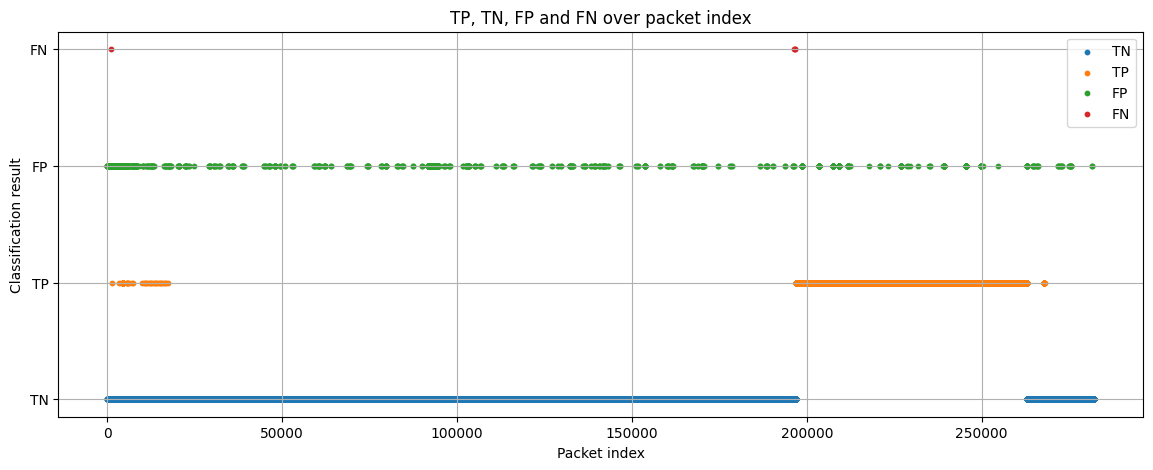

In [23]:
plt.figure(figsize=(14, 5))

classification_y = {
    "TN": 0,
    "TP": 1,
    "FP": 2,
    "FN": 3
}

results_df["plot_y"] = results_df["classification"].map(classification_y)

for label in ["TN", "TP", "FP", "FN"]:
    subset = results_df[results_df["classification"] == label]
    plt.scatter(
        subset["sequence_index"],
        subset["plot_y"],
        label=label,
        s=10
    )

plt.yticks(
    [0, 1, 2, 3],
    ["TN", "TP", "FP", "FN"]
)

plt.xlabel("Packet index")
plt.ylabel("Classification result")
plt.title("TP, TN, FP and FN over packet index")
plt.legend()
plt.grid(True)
plt.show()